# Clustering & Trees

This tutorial builds a self-alignment of a set of related sequences, computes
pairwise similarity with [sourmash](https://sourmash.readthedocs.io) sketches,
draws a hierarchical clustering tree on the dot-plot matrix, assigns the
sequences to clusters with an identity + coverage rule, and renders a
similarity heatmap with the tree and cluster outlines.

It needs the optional `cluster` extra:

```bash
pip install "dot-explorer[cluster]"   # sourmash + scipy
```

See [Similarity & Clustering](../clustering.md) for guidance on choosing
between the metrics used below.

## Build a sequence family

We synthesise six sequences with known relationships:

- **chrA1 / chrA2** — structural variants: chrA2 shares its first 55 kb
  with chrA1 exactly, with a different 5 kb tail.
- **chrA3** — chrA1 with 2% uniformly random SNPs (≈98% identical, but
  sharing no long exact stretches — a deliberate edge case, see below).
- **chrB1 / chrB2** — an unrelated structural-variant pair.
- **fragA** — a 15 kb fragment nested inside chrA1 (it will only cluster
  with its parent when coverage is *not* required to be reciprocal).

In [1]:
import random

from dot_explorer import DotPlotter, SequenceIndex

rng = random.Random(11)


def random_seq(n):
    return ''.join(rng.choice('ACGT') for _ in range(n))


def mutate(seq, rate):
    bases = 'ACGT'
    out = []
    for base in seq:
        if rng.random() < rate:
            out.append(rng.choice([b for b in bases if b != base]))
        else:
            out.append(base)
    return ''.join(out)


chrA1 = random_seq(60_000)
chrA2 = chrA1[:55_000] + random_seq(5_000)      # SV pair: 55 kb exact overlap
chrA3 = mutate(chrA1, 0.02)                     # ~98% identical, SNP-diverged
chrB1 = random_seq(45_000)
chrB2 = chrB1[:40_000] + random_seq(5_000)      # second SV pair
fragA = chrA1[5_000:20_000]                     # nested fragment of chrA1

seqs = {
    'chrA1': chrA1, 'chrA2': chrA2, 'chrA3': chrA3,
    'chrB1': chrB1, 'chrB2': chrB2, 'fragA': fragA,
}
index = SequenceIndex(k=15)
for name, seq in seqs.items():
    index.add_sequence(name, seq)
names = list(seqs)
names

['chrA1', 'chrA2', 'chrA3', 'chrB1', 'chrB2', 'fragA']

## Sketch and compare

`compute_sketches` builds one FracMinHash sketch per sequence. These are
short sequences, so we lower `scaled` to 50 (one hash per ~50 bp) — this
keeps enough hashes per sketch for stable estimates and tight ANI
confidence intervals. Abundance tracking is on by default (sourmash's
`-p abund`), which the angular metric requires.

In [2]:
from dot_explorer import SketchParams, compute_sketches, pairwise_similarity

params = SketchParams(ksize=21, scaled=50, track_abundance=True)
sketches = compute_sketches(index, names, params=params)

jaccard = pairwise_similarity(sketches, metric='jaccard')
angular = pairwise_similarity(sketches, metric='angular')

The raw similarity matrix is a numpy array with named rows/columns —
print it, or export it with `to_csv`:

In [3]:
import numpy as np

print('Jaccard similarity:')
print('        ' + '  '.join(f'{n:>6}' for n in jaccard.names))
for name, row in zip(jaccard.names, np.round(jaccard.values, 3)):
    print(f'{name:>7} ' + '  '.join(f'{v:6.3f}' for v in row))

Jaccard similarity:
         chrA1   chrA2   chrA3   chrB1   chrB2   fragA
  chrA1  1.000   0.841   0.442   0.000   0.000   0.254
  chrA2  0.841   1.000   0.391   0.000   0.000   0.253
  chrA3  0.442   0.391   1.000   0.000   0.000   0.138
  chrB1  0.000   0.000   0.000   1.000   0.802   0.000
  chrB2  0.000   0.000   0.000   0.802   1.000   0.000
  fragA  0.254   0.253   0.138   0.000   0.000   1.000


## Cluster and draw the tree on the matrix

`linkage_from_similarity` runs UPGMA on `1 − similarity`;
`Tree.from_linkage` turns the linkage into a tree whose leaf order fixes
the plot's row and column order. The dashed line marks a similarity
cutoff of 0.5 (drawn at distance `1 − 0.5` from the tips).

Tree order: ['chrB1', 'chrB2', 'fragA', 'chrA3', 'chrA1', 'chrA2']


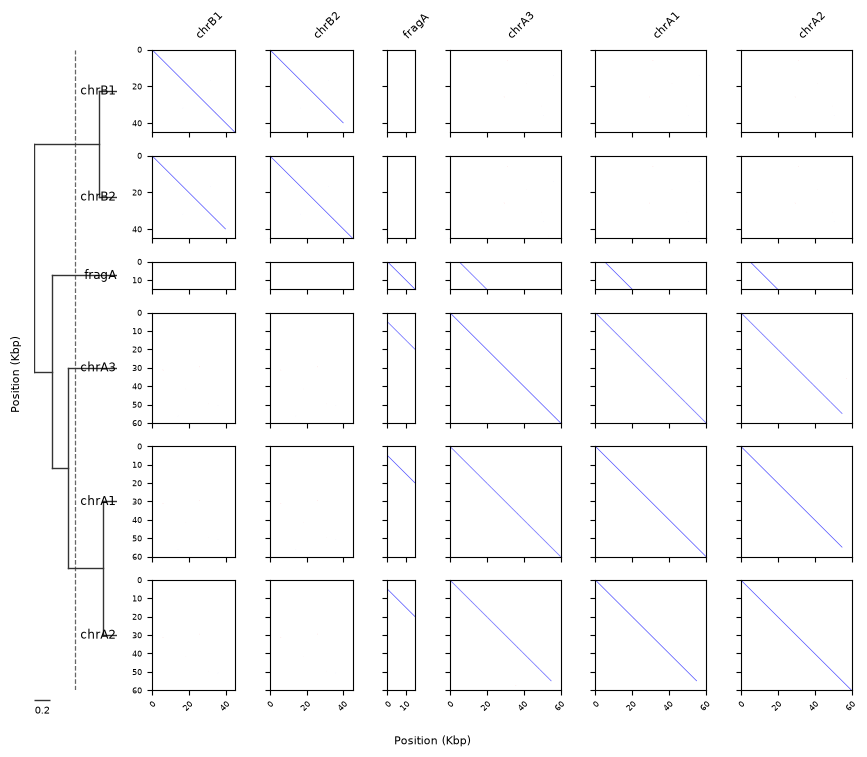

In [4]:
from dot_explorer import Tree, linkage_from_similarity

Z = linkage_from_similarity(jaccard, method='average')
tree = Tree.from_linkage(Z, jaccard.names)
print('Tree order:', tree.leaf_names())

plotter = DotPlotter(index)
fig = plotter.plot(tree=tree, tree_cutoff=0.5, figsize_per_panel=1.6)

## Assign clusters: identity ≥ 80% over ≥ 80% reciprocal coverage

The "80/80" rule combines two matrices: ANI as the identity estimate and
containment as the coverage analogue. With `reciprocal=True` both
directions must clear 80% coverage — so `fragA`, though 100% identical
to part of `chrA1`, stays out of the chrA cluster (chrA1 is only ~25%
covered by the fragment).

**A k-mer caveat worth understanding:** containment counts *exact*
shared k-mers, so uniformly scattered SNPs depress it steeply — at 98%
identity roughly `1 − 0.98²¹ ≈ 35%` of all 21-mers are destroyed. Watch
`chrA3` below: its ANI to chrA1 is ~0.98, but its containment is only
~0.65, so the 80% coverage bar excludes it. The 80/80 rule with sketch
containment therefore groups sequences sharing long (near-)exact
stretches, like the SV pairs here; for SNP-diverged families, lower the
coverage cutoff (roughly `coverage × ANI^k`) or cluster on a similarity
cutoff with `assign_clusters` instead.

In [5]:
from dot_explorer import assign_clusters_dual

ani = pairwise_similarity(sketches, metric='ani')
containment = pairwise_similarity(sketches, metric='containment')

for a, b in [('chrA1', 'chrA2'), ('chrA1', 'chrA3')]:
    i, j = ani.names.index(a), ani.names.index(b)
    print(
        f'ANI {a} vs {b}: {ani.values[i, j]:.4f} '
        f'(95% CI {ani.ci_low[i, j]:.4f}-{ani.ci_high[i, j]:.4f}), '
        f'containment {containment[(a, b)]:.3f}'
    )
print(f"fragA contained in chrA1: {containment[('fragA', 'chrA1')]:.3f}")
print(f"chrA1 contained in fragA: {containment[('chrA1', 'fragA')]:.3f}")

clusters = assign_clusters_dual(
    ani,
    containment,
    identity_cutoff=0.80,
    coverage_cutoff=0.80,
    reciprocal=True,
)
clusters.clusters

ANI chrA1 vs chrA2: 0.9958 (95% CI 0.9947-0.9967), containment 0.916
ANI chrA1 vs chrA3: 0.9777 (95% CI 0.9752-0.9801), containment 0.623
fragA contained in chrA1: 1.000
chrA1 contained in fragA: 0.254


{'cluster_1': ['chrA1', 'chrA2'],
 'cluster_2': ['chrA3'],
 'cluster_3': ['chrB1', 'chrB2'],
 'cluster_4': ['fragA']}

Passing the result as `cluster_borders` outlines each cluster's block of
panels in the matrix (bold black boxes). The two SV pairs cluster;
`fragA` fails the reciprocal-coverage bar and `chrA3` the containment
bar (the SNP caveat above), so both sit in singleton clusters.

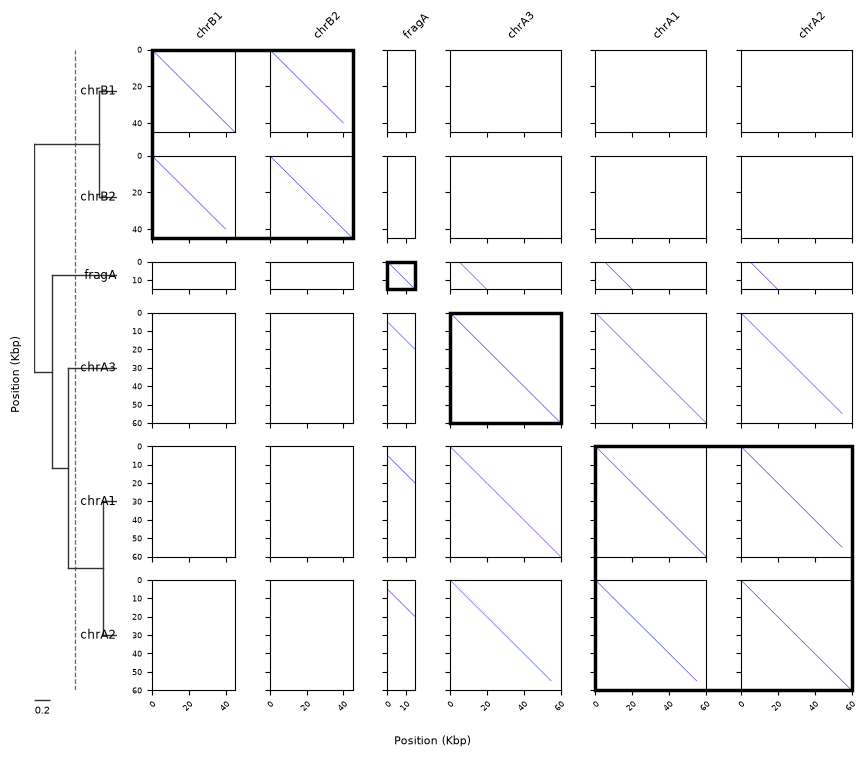

In [6]:
fig = plotter.plot(
    tree=tree,
    tree_cutoff=0.5,
    cluster_borders=clusters,
    figsize_per_panel=1.6,
)

## Similarity heatmap

The same matrix as a heatmap: tree left of the y-axis, cluster outlines,
and the colour scale bar at the right. Pick any matplotlib colormap.

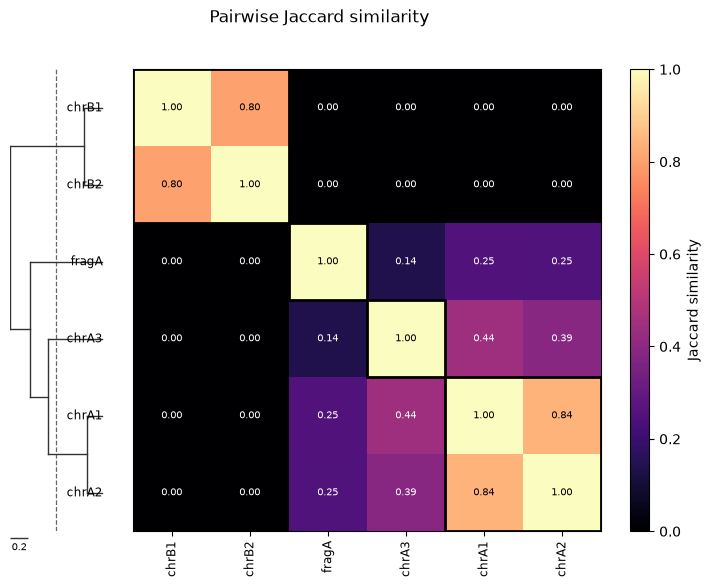

In [7]:
from dot_explorer import plot_similarity_heatmap

fig = plot_similarity_heatmap(
    jaccard,
    tree=tree,
    clusters=clusters,
    cutoff=0.5,
    cmap='magma',
    annotate=True,
    title='Pairwise Jaccard similarity',
)

## Export the results

Both the matrix and the cluster assignments write straight to CSV:

In [8]:
jaccard.to_csv('similarity_matrix.csv')
clusters.to_csv('cluster_assignments.csv')
print(open('cluster_assignments.csv').read())

contig,cluster
chrA1,cluster_1
chrA2,cluster_1
chrA3,cluster_2
chrB1,cluster_3
chrB2,cluster_3
fragA,cluster_4



## Using your own tree

A phylogenetic tree from IQ-TREE (`.treefile`) or any newick file plugs
into the same `tree=` argument via `Tree.read` — tip labels must match
the sequence names exactly (a mismatch raises an error listing what is
missing on each side), and the tree then fixes the contig order in place
of the sorting options:

User tree order: ['chrA1', 'chrA2', 'chrB1', 'chrB2', 'chrA3', 'fragA']


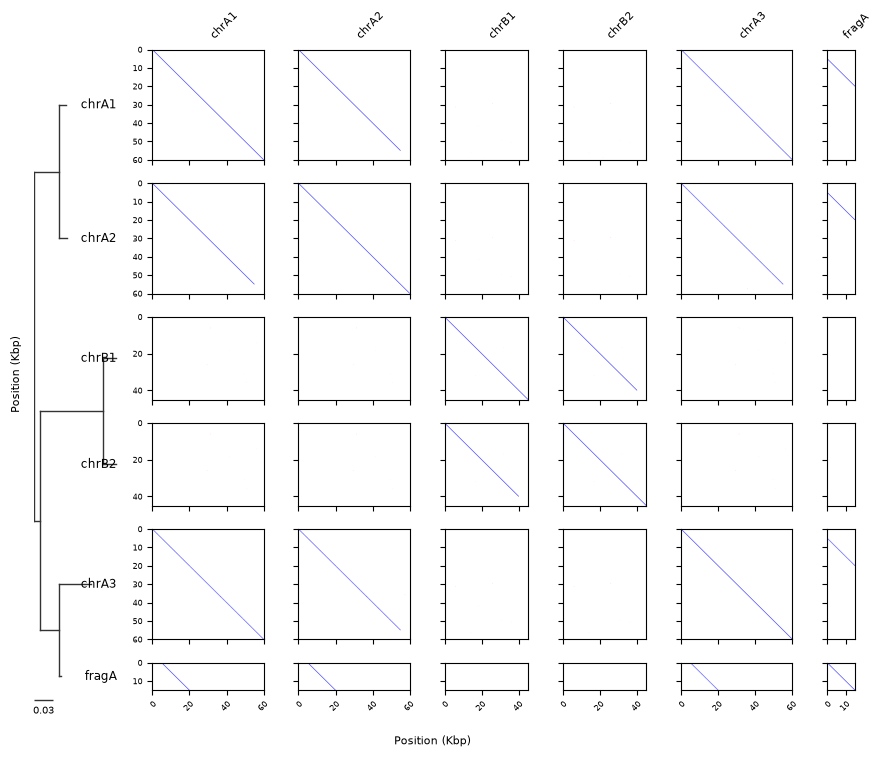

In [9]:
with open('my_tree.treefile', 'w') as fh:
    fh.write(
        '((chrA1:0.01,chrA2:0.012)98:0.04,((chrB1:0.02,chrB2:0.02)99:0.1,'
        '(chrA3:0.05,fragA:0.002)75:0.03):0.01);'
    )

user_tree = Tree.read('my_tree.treefile')
print('User tree order:', user_tree.leaf_names())
fig = plotter.plot(tree=user_tree, figsize_per_panel=1.6)

In [10]:
# Clean up the tutorial's output files.
import os

for path in ('similarity_matrix.csv', 'cluster_assignments.csv', 'my_tree.treefile'):
    os.remove(path)